In [11]:
import os
import csv
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 設定: ここを自分のデータに合わせて調整 ---
# CSV形式: class_name, x1, y1, s1, x2, y2, s2, ... (17点分)
# 元のノートブックで生成したtrain_data.csvがあることを想定しています
DATASET_CSV = 'train_data.csv' 
MODEL_SAVE_PATH = 'pose_classifier.tflite'
LABEL_SAVE_PATH = 'pose_labels.txt'

def train_and_export_model():
    if not os.path.exists(DATASET_CSV):
        print(f"エラー: {DATASET_CSV} が見つかりません。先に画像から特徴量を抽出してCSVを作成してください。")
        return

    # 1. データの読み込み
    def load_csv(csv_path):
        with open(csv_path, 'r') as f:
            reader = csv.reader(f)
            data = list(reader)
        
        # ラベルのユニーク値を取得してID化
        classes = sorted(list(set([row[0] for row in data])))
        with open(LABEL_SAVE_PATH, 'w') as f:
            for c in classes:
                f.write(c + '\n')
        
        X = np.array([row[1:] for row in data], dtype=np.float32)
        y = np.array([classes.index(row[0]) for row in data], dtype=np.int32)
        return X, y, classes

    X, y, class_names = load_csv(DATASET_CSV)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. モデルの構築 (非常に軽量な多層パーセプトロン)
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(51,)), # 17 points * 3 (x, y, score)
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dropout(0.3),
        tf.keras.layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    # 3. 学習
    print("Training model...")
    model.fit(X_train, y_train, epochs=200, batch_size=16, 
              validation_data=(X_test, y_test), verbose=0)
    
    loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
    print(f"Test Accuracy: {accuracy:.4f}")

    # 4. TFLite 形式へ変換・保存
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()

    with open(MODEL_SAVE_PATH, 'wb') as f:
        f.write(tflite_model)
    
    print(f"Success: '{MODEL_SAVE_PATH}' and '{LABEL_SAVE_PATH}' created.")

train_and_export_model()

エラー: train_data.csv が見つかりません。先に画像から特徴量を抽出してCSVを作成してください。


In [14]:
import os
import glob
import csv
import tqdm
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split

# --- 設定 ---
DATASET_ROOT = 'Dataset' # 'Dataset/Train' などに合わせて調整してください
TRAIN_DIR = os.path.join(DATASET_ROOT, 'Train')
MODEL_SAVE_PATH = 'pose_classifier.tflite'
LABEL_SAVE_PATH = 'pose_labels.txt'

# --- 1. MoveNetのセットアップ ---
movenet_interpreter = tf.lite.Interpreter(model_path="movenet_thunder.tflite")
movenet_interpreter.allocate_tensors()

def run_movenet_inference(image_path):
    """画像から17個のキーポイント(y, x, score)を抽出する"""
    image = tf.io.read_file(image_path)
    image = tf.image.decode_jpeg(image)
    
    # MoveNet Thunderの入力サイズ(256x256)にリサイズ
    input_size = 256
    input_image = tf.expand_dims(image, axis=0)
    input_image = tf.image.resize_with_pad(input_image, input_size, input_size)
    input_image = tf.cast(input_image, dtype=tf.uint8)

    input_details = movenet_interpreter.get_input_details()
    output_details = movenet_interpreter.get_output_details()

    movenet_interpreter.set_tensor(input_details[0]['index'], input_image.numpy())
    movenet_interpreter.invoke()

    # [1, 1, 17, 3]
    keypoints_with_scores = movenet_interpreter.get_tensor(output_details[0]['index'])
    return keypoints_with_scores[0][0].flatten() # 51要素のベクトル

# --- 2. 特徴量抽出 (画像 -> 座標CSV) ---
def prepare_dataset(target_dir):
    print(f"Extracting features from {target_dir}...")
    # ポーズ名（フォルダ名）を取得
    classes = [d for d in os.listdir(target_dir) if os.path.isdir(os.path.join(target_dir, d))]
    classes.sort()
    
    X = []
    y = []
    
    for class_idx, class_name in enumerate(classes):
        image_paths = glob.glob(os.path.join(target_dir, class_name, "*.jpg"))
        print(f" Processing '{class_name}': {len(image_paths)} images")
        
        for img_path in tqdm.tqdm(image_paths):
            try:
                features = run_movenet_inference(img_path)
                X.append(features)
                y.append(class_idx)
            except Exception as e:
                print(f"  Error processing {img_path}: {e}")
                
    return np.array(X), np.array(y), classes

# --- 実行 ---
if not os.path.exists(TRAIN_DIR):
    print(f"エラー: {TRAIN_DIR} が見つかりません。パスを確認してください。")
else:
    # A. 特徴量抽出
    X, y, class_names = prepare_dataset(TRAIN_DIR)
    
    # B. ラベルファイルの保存
    with open(LABEL_SAVE_PATH, 'w') as f:
        for name in class_names:
            f.write(name + '\n')
    
    # C. 学習用と検証用に分割
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.15, random_state=42)

    # D. 分類モデルの定義
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(input_shape=(51,)),
        tf.keras.layers.Dense(128, activation='relu'),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(64, activation='relu'),
        tf.keras.layers.Dense(len(class_names), activation='softmax')
    ])

    model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

    # E. 学習実行
    print("\nTraining classifier model...")
    model.fit(X_train, y_train, epochs=100, batch_size=16, validation_data=(X_val, y_val), verbose=1)

    # F. TFLite形式で保存
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    tflite_model = converter.convert()
    with open(MODEL_SAVE_PATH, 'wb') as f:
        f.write(tflite_model)

    print(f"\n完了！ '{MODEL_SAVE_PATH}' と '{LABEL_SAVE_PATH}' が作成されました。")

C:\Users\ITWhiteHacker\.conda\envs\yoga-env\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Extracting features from Dataset\Train...
 Processing 'downdog': 199 images


100%|████████████████████████████████████████████████████████████████████████████████| 199/199 [00:07<00:00, 27.99it/s]


 Processing 'goddess': 168 images


100%|████████████████████████████████████████████████████████████████████████████████| 168/168 [00:06<00:00, 27.05it/s]


...


Training classifier model...
Epoch 1/100



C:\Users\ITWhiteHacker\.conda\envs\yoga-env\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2650 - loss: 1.5733 - val_accuracy: 0.3667 - val_loss: 1.4695
Epoch 2/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.3793 - loss: 1.4268 - val_accuracy: 0.5267 - val_loss: 1.2843
Epoch 3/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4700 - loss: 1.2515 - val_accuracy: 0.5467 - val_loss: 1.0989
Epoch 4/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5312 - loss: 1.1157 - val_accuracy: 0.5733 - val_loss: 0.9716
Epoch 5/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5595 - loss: 1.0198 - val_accuracy: 0.6867 - val_loss: 0.8957
Epoch 6/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6196 - loss: 0.9375 - val_accuracy: 0.7800 - val_loss: 0.8275
Epoch 7/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6349 - loss: 0.8861 - val_accuracy: 0.7200 - val_loss: 0.7789
Epoch 8/100
54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6514 - loss: 0.8417 - val_accuracy: 0.7000 - val_loss: 0.7

INFO:tensorflow:Assets written to: C:\Users\ITWHIT~1\AppData\Local\Temp\tmpa4kc7u6v\assets


Saved artifact at 'C:\Users\ITWHIT~1\AppData\Local\Temp\tmpa4kc7u6v'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 51), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  2433341255184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2433341256528: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2433341254992: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2433341256912: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2433341254032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2433341257296: TensorSpec(shape=(), dtype=tf.resource, name=None)

完了！ 'pose_classifier.tflite' と 'pose_labels.txt' が作成されました。


Result: warrior2 (57.2%)
Visualization error: 'Person' object has no attribute 'id'. Showing raw image.


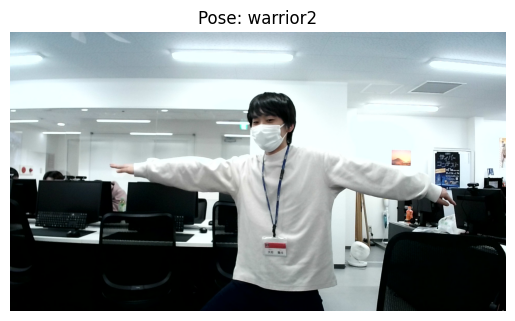

In [17]:
import os
import sys
import cv2
import numpy as np
import tensorflow as tf
from matplotlib import pyplot as plt
from urllib import request
from collections import namedtuple

# --- 1. 環境準備 ---
def setup_environment():
    movenet_url = "https://tfhub.dev/google/lite-model/movenet/singlepose/thunder/tflite/float16/4?lite-format=tflite"
    if not os.path.exists('movenet_thunder.tflite'):
        request.urlretrieve(movenet_url, 'movenet_thunder.tflite')

    if not os.path.exists('examples'):
        !git clone https://github.com/tensorflow/examples.git
    
    pose_path = os.path.join(os.getcwd(), 'examples/lite/examples/pose_estimation/raspberry_pi')
    if pose_path not in sys.path:
        sys.path.append(pose_path)

setup_environment()

# utilsから必要な関数だけをインポート
import utils

# エラーを回避するため、必要なデータ構造を再定義
# utils内の定義と競合しないよう、内部で使用する構造を整理します
Point = namedtuple('Point', ['x', 'y'])
KeyPoint = namedtuple('KeyPoint', ['body_part', 'coordinate', 'score'])
Rectangle = namedtuple('Rectangle', ['start_point', 'end_point'])
Person = namedtuple('Person', ['keypoints', 'bounding_box', 'score'])

# --- 2. 推論エンジンの定義 ---
class PoseClassifierApp:
    def __init__(self, movenet_path, classifier_path, label_path):
        self.movenet_interpreter = tf.lite.Interpreter(model_path=movenet_path)
        self.movenet_interpreter.allocate_tensors()
        
        self.classifier_interpreter = None
        if os.path.exists(classifier_path):
            self.classifier_interpreter = tf.lite.Interpreter(model_path=classifier_path)
            self.classifier_interpreter.allocate_tensors()
            
        self.labels = []
        if os.path.exists(label_path):
            with open(label_path, 'r') as f:
                self.labels = [line.strip() for line in f.readlines()]
        else:
            self.labels = ["Unknown"]

    def run_movenet(self, image_rgb):
        input_details = self.movenet_interpreter.get_input_details()
        output_details = self.movenet_interpreter.get_output_details()
        input_size = input_details[0]['shape'][1]
        
        image_resized = cv2.resize(image_rgb, (input_size, input_size))
        input_tensor = np.expand_dims(image_resized, axis=0).astype(np.uint8)

        self.movenet_interpreter.set_tensor(input_details[0]['index'], input_tensor)
        self.movenet_interpreter.invoke()
        return self.movenet_interpreter.get_tensor(output_details[0]['index'])[0][0]

    def classify(self, keypoints):
        if not self.classifier_interpreter:
            return "Classifier Not Loaded", 0.0
        
        input_data = keypoints.flatten().astype(np.float32).reshape(1, 51)
        c_input_idx = self.classifier_interpreter.get_input_details()[0]['index']
        c_output_idx = self.classifier_interpreter.get_output_details()[0]['index']
        
        self.classifier_interpreter.set_tensor(c_input_idx, input_data)
        self.classifier_interpreter.invoke()
        
        output_data = self.classifier_interpreter.get_tensor(c_output_idx)
        idx = np.argmax(output_data[0])
        return self.labels[idx], output_data[0][idx]

# --- 3. 実行メイン処理 ---
CLASSIFIER_TFLITE = 'pose_classifier.tflite'
LABEL_FILE = 'pose_labels.txt'
TEST_IMAGE = 'jarisanyokosuma.jpg' # ← 判定したいファイル名に変更

app = PoseClassifierApp('movenet_thunder.tflite', CLASSIFIER_TFLITE, LABEL_FILE)

if os.path.exists(TEST_IMAGE):
    img_bgr = cv2.imread(TEST_IMAGE)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w, _ = img_rgb.shape
    
    # MoveNet推論
    keypoints = app.run_movenet(img_rgb)
    
    # 描画用のデータ構造作成 (utils.visualize に渡す形式をエミュレート)
    # 多くの環境の utils.py では Person は単純なクラス/タプルを期待します
    kpts_list = []
    for i in range(17):
        # y, x, score の順で格納されているのを変換
        kpts_list.append(KeyPoint(body_part=i, 
                                  coordinate=Point(x=keypoints[i, 1] * w, y=keypoints[i, 0] * h), 
                                  score=keypoints[i, 2]))
    
    rect = Rectangle(start_point=Point(x=np.min(keypoints[:,1])*w, y=np.min(keypoints[:,0])*h),
                     end_point=Point(x=np.max(keypoints[:,1])*w, y=np.max(keypoints[:,0])*h))
    
    person = Person(keypoints=kpts_list, bounding_box=rect, score=np.mean(keypoints[:, 2]))
    
    # 分類推論
    pose_name, confidence = app.classify(keypoints)
    print(f"Result: {pose_name} ({confidence*100:.1f}%)")
    
    # 描画 (utils.visualizeがエラーになる場合は自前で描画)
    try:
        output_img = utils.visualize(img_rgb, [person])
        plt.figure(figsize=(10, 10))
        plt.imshow(output_img)
    except Exception as e:
        print(f"Visualization error: {e}. Showing raw image.")
        plt.imshow(img_rgb)

    plt.title(f"Pose: {pose_name}")
    plt.axis('off')
    plt.show()
else:
    print(f"画像 '{TEST_IMAGE}' が見つかりません。")